# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [24]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
mpg_data.head()

print("Dataset shape:", mpg_data.shape)
print("Number of rows:", mpg_data.shape[0])
print("Number of columns:", mpg_data.shape[1])


Dataset shape: (392, 9)
Number of rows: 392
Number of columns: 9


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [ ]:
# Your answer here...
# 392 Observations. 9 variables. 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [ ]:
# Your answer here...
# The variable type of the response variable mpg (miles per gallon) is float, as it contains real numbers with decimal points (e.g., 18.0, 15.0). 
# A float represents continuous numerical data, allowing for precise measurement of fuel efficiency.

Your explanation... 


_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [ ]:
# Your answer here... 
# 	mpg	cylinders	displacement	horsepower	weight	acceleration	model_year	origin	name
# 116	16.0	8	400.0	230.0	4278	9.5	73	usa	pontiac grand prix
# 95	12.0	8	455.0	225.0	4951	11.0	73	usa	buick electra 225 custom
# 8	14.0	8	455.0	225.0	4425	10.0	70	usa	pontiac catalina
# 13	14.0	8	455.0	225.0	3086	10.0	70	usa	buick estate wagon (sw)
# 6	14.0	8	454.0	220.0	4354	9.0	70	usa	chevrolet impala







,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala


_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [ ]:
# Your answer here...
# 8

You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

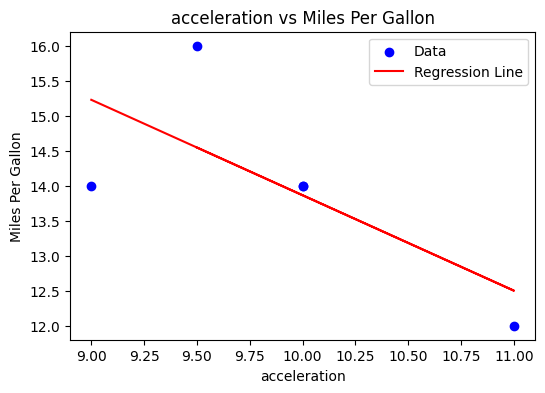

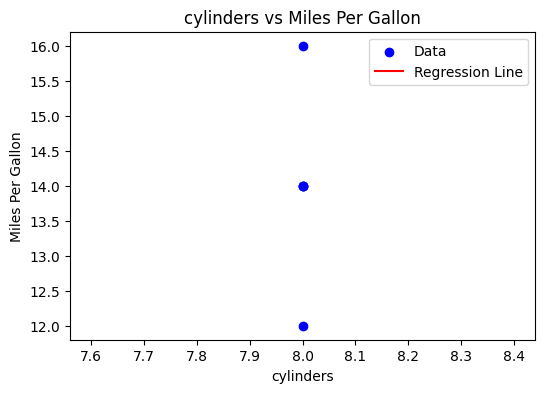

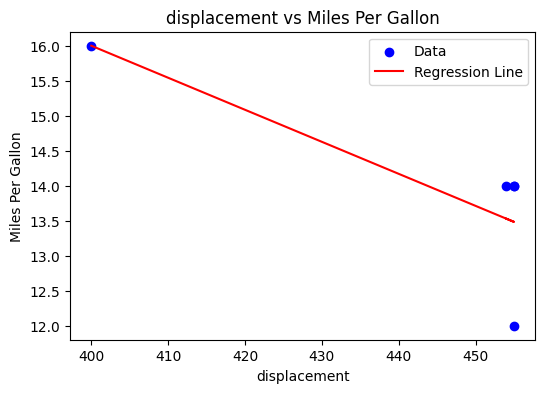

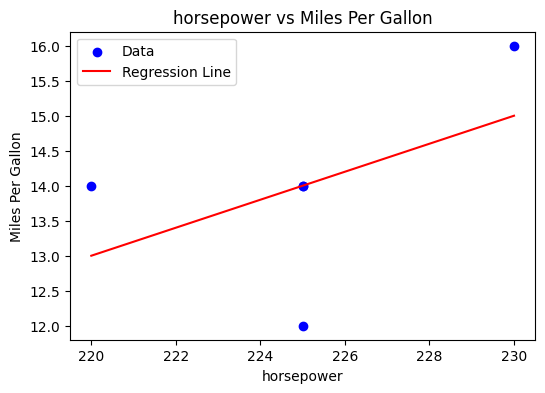

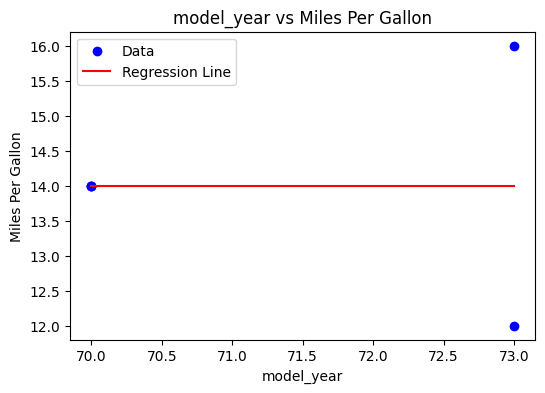

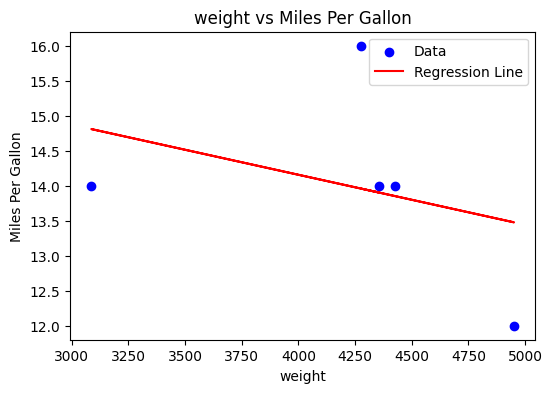

In [8]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='blue')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='red', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

> Your answer here...
Acceleration vs Miles Per Gallon: Negative Association
Cylinder vs Miles Per Gallon: No Association
Displacement vs Miles Per Gallon: Negative Association
Horsepower vs Miles Per Gallon: Positive Association
Model Year vs Miles Per Gallon: No Association
Weight vs Miles Per Gallon: Negative Association

_(ii)_ What concept ‘defines’ the plotted line?

> Your answer here...
Linear Regression

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

> Your answer here...
No, not all data points fall perfectly along the plotted line—and that is expected.
The red line represents the predictions made by a linear model, which assumes a straight-line relationship between a predictor variable and the response variable. However, there many other factors (predictor variables) that influence Miles Per Gallon.

#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [25]:
# Your answer here...
# Define predictors and response
X = mpg_data.drop(columns=['mpg'])
y = mpg_data['mpg']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

# Print shape to verify
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Dataset shape:", mpg_data.shape)
print("Number of rows:", mpg_data.shape[0])
print("Number of columns:", mpg_data.shape[1])


Train shape: (294, 8)
Test shape: (98, 8)
Dataset shape: (392, 9)
Number of rows: 392
Number of columns: 9


**Step 2: Fit the linear regression model.**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Step 1: Convert categorical columns to dummy variables
# This will convert all object-type columns to numeric columns (one-hot encoded)
mpg_data_encoded = pd.get_dummies(mpg_data, drop_first=True)

# Step 2: Define predictors and response after encoding
X = mpg_data_encoded.drop(columns=['mpg'])
y = mpg_data_encoded['mpg']

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

# Step 4: Fit the linear regression model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Step 5: Prepare coefficients DataFrame
coefficients_df = pd.DataFrame({
    "predictor": X_train.columns,
    "slope": lm.coef_,
    "intercept": [lm.intercept_] * len(lm.coef_)
})

print(coefficients_df)


                     predictor      slope  intercept
0                    cylinders  -0.937596  14.913497
1                 displacement   0.014544  14.913497
2                   horsepower  -0.068976  14.913497
3                       weight  -0.005976  14.913497
4                 acceleration  -0.653197  14.913497
..                         ...        ...        ...
303    name_vw dasher (diesel)  14.480264  14.913497
304             name_vw pickup   0.000000  14.913497
305             name_vw rabbit   7.375133  14.913497
306  name_vw rabbit c (diesel)  12.579968  14.913497
307      name_vw rabbit custom  -3.589841  14.913497

[308 rows x 3 columns]


#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [31]:
# Your code here ...
import numpy as np

# Predict on test data
y_pred = lm.predict(X_test)

# Calculate RMSPE
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2))

print(f"RMSPE on test set: {rmspe:.4f}")


RMSPE on test set: 0.2231


# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 05/25/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
